## Wayfair UK BSR Share 분석

In [6]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

In [7]:
import os
import sys

import io
from io import BytesIO
import csv

import google.auth
from google.cloud import bigquery
#from google.cloud import bigquery_storage

In [8]:
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = "./market-analysis-project-91130-9f9a036682b6.json"

credentials, project_id = google.auth.default(
    scopes=["https://www.googleapis.com/auth/cloud-platform"]
)

bqclient = bigquery.Client(credentials=credentials, project=project_id,)

In [12]:
sql = f"""
select * from mart.way_eu_bsr
"""

df = bqclient.query(sql).to_dataframe()

In [18]:
df.head(5)

,country,category,is_zinus_prod,sku,product_url,product_name,brand,ld_date_time,ld_date,yr_week,...,customer_price_discount_percentage,is_sponsored,has_stock,brand_oth,brand_legend_num,brand_oth_prod,brand_prod_legend_num,brand_legend_ord,brand_prod_legend_ord,page_label
0,UK,mattresses,N,U110295396,None,25cm Memory Foam Pocket Sprung Mattress,Novilla,2025-08-07 08:30:00,2025-08-07,Y25 W32,...,0.311702,1,1,Novilla,4751,Novilla,4751,15,15,p.2 (49~97)
1,UK,mattresses,N,U110295396,None,25cm Memory Foam Pocket Sprung Mattress,Novilla,2025-08-06 08:30:00,2025-08-06,Y25 W32,...,0.311702,1,1,Novilla,4751,Novilla,4751,15,15,p.2 (49~97)
2,UK,mattresses,N,U110295396,None,25cm Memory Foam Pocket Sprung Mattress,Novilla,2025-07-14 08:30:00,2025-07-14,Y25 W29,...,0.487610,1,1,Novilla,4751,Novilla,4751,15,15,p.1 (1~48)
3,UK,mattresses,N,U110295396,None,25cm Memory Foam Pocket Sprung Mattress,Novilla,2025-07-09 08:30:00,2025-07-09,Y25 W28,...,0.487610,1,1,Novilla,4751,Novilla,4751,15,15,p.1 (1~48)
4,UK,mattresses,N,U110295396,None,25cm Memory Foam Pocket Sprung Mattress,Novilla,2025-07-28 08:30:00,2025-07-28,Y25 W31,...,0.441721,1,1,Novilla,4751,Novilla,4751,15,15,p.2 (49~97)


In [26]:
df_uk = df[(df['country']=='UK') & (df['page_label']=='p.1 (1~48)') & (df['category']=='beds')]

In [28]:
print(df_uk)

       country category is_zinus_prod         sku  \
5290        UK     beds             N  U110635389   
5737        UK     beds             N  U100061546   
5739        UK     beds             N  U100061546   
5740        UK     beds             N  U100061546   
5741        UK     beds             N  U100061546   
...        ...      ...           ...         ...   
130993      UK     beds             N    LSSS1284   
131001      UK     beds             N    LSSS1284   
131003      UK     beds             N    LSSS1284   
131014      UK     beds             N    LSSS1284   
131030      UK     beds             N    LSSS1284   

                                              product_url  \
5290                                                 None   
5737                                                 None   
5739                                                 None   
5740                                                 None   
5741                                                 None 

In [34]:
# 주별 집계
zinus_weekly = (
    df_uk.groupby('yr_week')
      .agg(
          total_count=('is_zinus_prod', 'count'),
          zinus_count=('is_zinus_prod', lambda x: (x == 'Y').sum())
      )
      .reset_index()
)

# 점유율 계산
zinus_weekly['zinus_share'] = zinus_weekly['zinus_count'] / zinus_weekly['total_count']
zinus_weekly['zinus_share_pct'] = zinus_weekly['zinus_share'] * 100  # 퍼센트 표시

print(zinus_weekly)

    yr_week  total_count  zinus_count  zinus_share  zinus_share_pct
0   Y24 W50           96           44     0.458333        45.833333
1   Y24 W51          336          151     0.449405        44.940476
2   Y24 W52          336          144     0.428571        42.857143
3   Y25 W01          336          138     0.410714        41.071429
4   Y25 W02          288          130     0.451389        45.138889
5   Y25 W03          336          138     0.410714        41.071429
6   Y25 W04          336          116     0.345238        34.523810
7   Y25 W05          336          141     0.419643        41.964286
8   Y25 W06          336          136     0.404762        40.476190
9   Y25 W07          336          134     0.398810        39.880952
10  Y25 W08          336          130     0.386905        38.690476
11  Y25 W09          336          132     0.392857        39.285714
12  Y25 W10          336           95     0.282738        28.273810
13  Y25 W11          288           88     0.3055

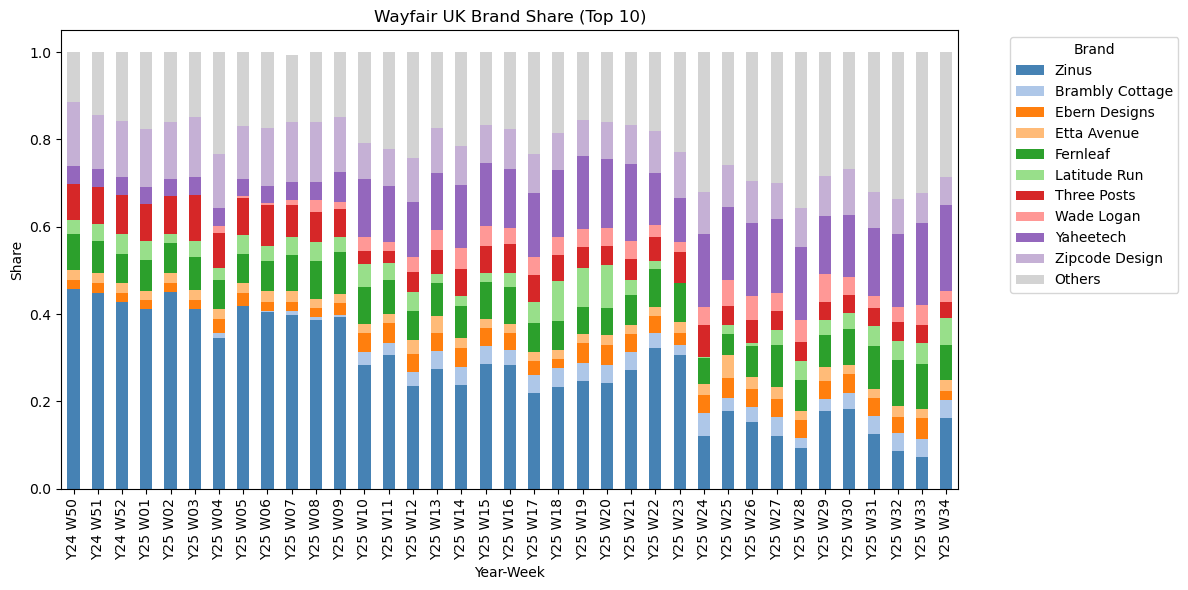

In [50]:
# === 0. 전처리: 지누스 표시 ===
df1 = df_uk.copy()
df1.loc[df['is_zinus_prod'] == 'Y', 'brand'] = 'Zinus'

# === 1. 주별, 브랜드별 row 개수 ===
weekly_brand_counts = (
    df1.groupby(['yr_week', 'brand'])
      .size()
      .reset_index(name='brand_count')
)

# === 2. 주별 전체 row 개수 ===
weekly_total = (
    df1.groupby('yr_week')
      .size()
      .reset_index(name='total_count')
)

# === 3. merge 해서 점유율 계산 ===
weekly_brand_counts = weekly_brand_counts.merge(weekly_total, on='yr_week')
weekly_brand_counts['share'] = weekly_brand_counts['brand_count'] / weekly_brand_counts['total_count']

# === 4. 전체 기간 합산 후 Top 10 브랜드 선정 ===
top_brands = (
    weekly_brand_counts.groupby('brand')['brand_count']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .index
)

# === 5. Top 10 이외는 Others로 변환 ===
weekly_brand_counts['brand_adj'] = weekly_brand_counts['brand'].where(
    weekly_brand_counts['brand'].isin(top_brands),
    'Others'
)

# === 6. 주별 다시 집계 (Others 포함) ===
weekly_top = (
    weekly_brand_counts.groupby(['yr_week', 'brand_adj'])
    .agg({'brand_count': 'sum', 'total_count': 'first'})
    .reset_index()
)
weekly_top['share'] = weekly_top['brand_count'] / weekly_top['total_count']

# === 7. 피벗 테이블 ===
pivot_df = weekly_top.pivot(index='yr_week', columns='brand_adj', values='share').fillna(0)

# === 8. 컬럼 순서 조정 (Zinus 아래, Others 위) ===
cols = list(pivot_df.columns)

ordered_cols = []
if 'Zinus' in cols:
    ordered_cols.append('Zinus')  # 맨 아래
for c in cols:
    if c not in ['Zinus', 'Others']:
        ordered_cols.append(c)    # 중간
if 'Others' in cols:
    ordered_cols.append('Others') # 맨 위

pivot_df = pivot_df[ordered_cols]

# === 9. 색상 지정 (Others 회색) ===
default_colors = plt.cm.tab20.colors  # 기본 팔레트
color_map = {}

for i, col in enumerate(pivot_df.columns):
    if col == 'Others':
        color_map[col] = 'lightgrey'
    elif col == 'Zinus':
        color_map[col] = 'steelblue'  # Zinus는 파란색 예시
    else:
        color_map[col] = default_colors[i % len(default_colors)]

colors = [color_map[c] for c in pivot_df.columns]

# === 10. 누적 막대 그래프 ===
pivot_df.plot(kind='bar', stacked=True, figsize=(12,6), color=colors)

plt.title('Wayfair UK Brand Share (Top 10)')
plt.xlabel('Year-Week')
plt.ylabel('Share')
plt.legend(title='Brand', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()